#📌 Extracción

¿Qué debes hacer?

✅ Cargar los datos directamente desde la API utilizando Python.

✅ Convertir los datos a un DataFrame de Pandas para facilitar su manipulación.

In [3]:
import pandas as pd
import requests

In [4]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#🔧 Transformación

##Conoce el conjunto de datos
✅ Explorar las columnas del dataset y verificar sus tipos de datos.

✅ Consultar el diccionario para comprender mejor el significado de las variables.

✅ Identificar las columnas más relevantes para el análisis de evasión.

In [6]:
#Normalizar el dataset
df_norm = pd.json_normalize(data)
df_norm.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [9]:
df_norm.shape

(7267, 21)

In [10]:
df_norm.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

##Identificar valores unicos

In [14]:
#Vamos a ver los valores unicos por columna
df_norm.nunique()

,0
customerID,7267
Churn,3
customer.gender,2
customer.SeniorCitizen,2
customer.Partner,2
customer.Dependents,2
customer.tenure,73
phone.PhoneService,2
phone.MultipleLines,3
internet.InternetService,3


##Comprobación de incoherencias en los datos

In [19]:
#verificamos los datos unicos del cliente
print('Datos unicos en Churn:',df_norm.Churn.unique())
print('Datos unicos en Customer Gender:',df_norm["customer.gender"].unique())
print('Datos unicos en Customer SeniorCitizen:',df_norm["customer.SeniorCitizen"].unique())
print('Datos unicos en Customer Partner:',df_norm["customer.Partner"].unique())
print('Datos unicos en Customer Dependents:',df_norm["customer.Dependents"].unique())
print('Datos unicos en Customer Tenure:',df_norm["customer.tenure"].unique())

Datos unicos en Churn: ['No' 'Yes' '']
Datos unicos en Customer Gender: ['Female' 'Male']
Datos unicos en Customer SeniorCitizen: [0 1]
Datos unicos en Customer Partner: ['Yes' 'No']
Datos unicos en Customer Dependents: ['Yes' 'No']
Datos unicos en Customer Tenure: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]


In [21]:
#buscamos valores vacios en churn, ya que podemos ver en el informe anterior que existen vacios a pesar que no hay valores null
df_norm[df_norm['Churn']=='']

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
30,0047-ZHDTW,,Female,0,No,No,11,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),79.00,929.3
75,0120-YZLQA,,Male,0,No,No,71,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1355.1
96,0154-QYHJU,,Male,0,No,No,29,Yes,No,DSL,...,Yes,No,Yes,No,No,One year,Yes,Electronic check,58.75,1696.2
98,0162-RZGMZ,,Female,1,No,No,5,Yes,No,DSL,...,Yes,No,Yes,No,No,Month-to-month,No,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,Male,1,Yes,No,65,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,Yes,One year,Yes,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9840-GSRFX,,Female,0,No,No,14,Yes,Yes,DSL,...,Yes,No,No,No,No,One year,Yes,Mailed check,54.25,773.2
7180,9872-RZQQB,,Female,0,Yes,No,49,No,No phone service,DSL,...,No,No,No,Yes,No,Month-to-month,No,Bank transfer (automatic),40.65,2070.75
7211,9920-GNDMB,,Male,0,No,No,9,Yes,Yes,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,76.25,684.85
7239,9955-RVWSC,,Female,0,Yes,Yes,67,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),19.25,1372.9


##Manejo de inconsistencias

In [30]:
#copiamos el dataframe sin los valores vacios a uno nuevo
df = df_norm[df_norm['Churn']!=''].copy()
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [36]:
#aun hay blancos en charges total, hay que quitarlo
df[df['account.Charges.Total']==' ']


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
945,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1731,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1906,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2025,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2176,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2250,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2855,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3052,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3118,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4054,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [38]:
#hacemos una copia de los datos sin los blancos para limpiarlos
df = df[df['account.Charges.Total']!=' '].copy()
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7039,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7040,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7041,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [39]:
#reseteamos el index para que no se salte ningun numero
df.reset_index(drop=True, inplace=True)
df

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7028,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7029,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7030,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [40]:
#cambiamos el nombre de las columnas para un mejor entendimiento
df = df.rename(columns={
    'customerID':'id',
    'Churn':'churn',
    'customer.gender':'gender',
    'customer.SeniorCitizen':'senior',
    'customer.Partner':'partner',
    'customer.Dependents':'dependents',
    'customer.tenure':'tenure',
    'phone.PhoneService':'phone_service',
    'phone.MultipleLines':'phone_multiple_lines',
    'internet.InternetService':'internet_service',
    'internet.OnlineSecurity':'internet_security',
    'internet.OnlineBackup':'internet_online_backup',
    'internet.DeviceProtection':'internet_protection',
    'internet.TechSupport':'internet_tech_support',
    'internet.StreamingTV':'internet_streaming_tv',
    'internet.StreamingMovies':'internet_streaming_movies',
    'account.Contract':'account_contract',
    'account.PaperlessBilling':'account_paperless_billing',
    'account.PaymentMethod':'account_payment_method',
    'account.Charges.Monthly':'account_charges_monthly',
    'account.Charges.Total':'account_charges_total'
},)
df.head()

,id,churn,gender,senior,partner,dependents,tenure,phone_service,phone_multiple_lines,internet_service,...,internet_online_backup,internet_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


##Columna de cuentas diarias (Opcional)

In [41]:
df['account_charges_daily'] = round(df['account_charges_monthly']/30,2)
df

,id,churn,gender,senior,partner,dependents,tenure,phone_service,phone_multiple_lines,internet_service,...,internet_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total,account_charges_daily
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.9,1.84
7028,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,2.84
7029,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7030,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         7032 non-null   object 
 1   churn                      7032 non-null   object 
 2   gender                     7032 non-null   object 
 3   senior                     7032 non-null   int64  
 4   partner                    7032 non-null   object 
 5   dependents                 7032 non-null   object 
 6   tenure                     7032 non-null   int64  
 7   phone_service              7032 non-null   object 
 8   phone_multiple_lines       7032 non-null   object 
 9   internet_service           7032 non-null   object 
 10  internet_security          7032 non-null   object 
 11  internet_online_backup     7032 non-null   object 
 12  internet_protection        7032 non-null   object 
 13  internet_tech_support      7032 non-null   objec

In [44]:
print('Datos duplicados',df.duplicated().sum())

Datos duplicados 0


In [45]:
df['account_charges_total'] = pd.to_numeric(df['account_charges_total'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         7032 non-null   object 
 1   churn                      7032 non-null   object 
 2   gender                     7032 non-null   object 
 3   senior                     7032 non-null   int64  
 4   partner                    7032 non-null   object 
 5   dependents                 7032 non-null   object 
 6   tenure                     7032 non-null   int64  
 7   phone_service              7032 non-null   object 
 8   phone_multiple_lines       7032 non-null   object 
 9   internet_service           7032 non-null   object 
 10  internet_security          7032 non-null   object 
 11  internet_online_backup     7032 non-null   object 
 12  internet_protection        7032 non-null   object 
 13  internet_tech_support      7032 non-null   objec

#📊 Carga y análisis

In [42]:
df.describe()

,senior,tenure,account_charges_monthly,account_charges_daily
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2.159891
std,0.368844,24.545260,30.085974,1.002955
min,0.000000,1.000000,18.250000,0.610000
25%,0.000000,9.000000,35.587500,1.187500
50%,0.000000,29.000000,70.350000,2.340000
75%,0.000000,55.000000,89.862500,2.992500
max,1.000000,72.000000,118.750000,3.960000


##Distribucion de Evasión

In [46]:
#investigando el porcentaje de clientes que abandonaron el servicio
df['churn'].value_counts(normalize=True) * 100

,proportion
churn,
No,73.421502
Yes,26.578498


<Axes: title={'center': 'Porcentaje de clientes que abandonaron el servicio'}, ylabel='churn'>

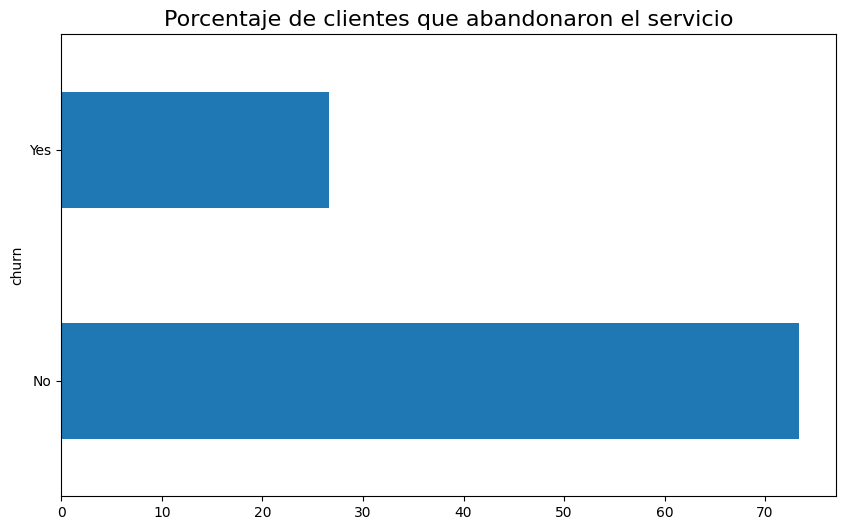

In [52]:
import matplotlib.pyplot as plt
churn_data = df['churn'].value_counts(normalize=True) * 100
plt.title('Porcentaje de clientes que abandonaron el servicio', fontsize=16)
plt.xlabel('Porcentaje', fontsize=14)
churn_data.plot(kind= 'barh', figsize = (10,6))

##Recuento de evasión por variables categóricas

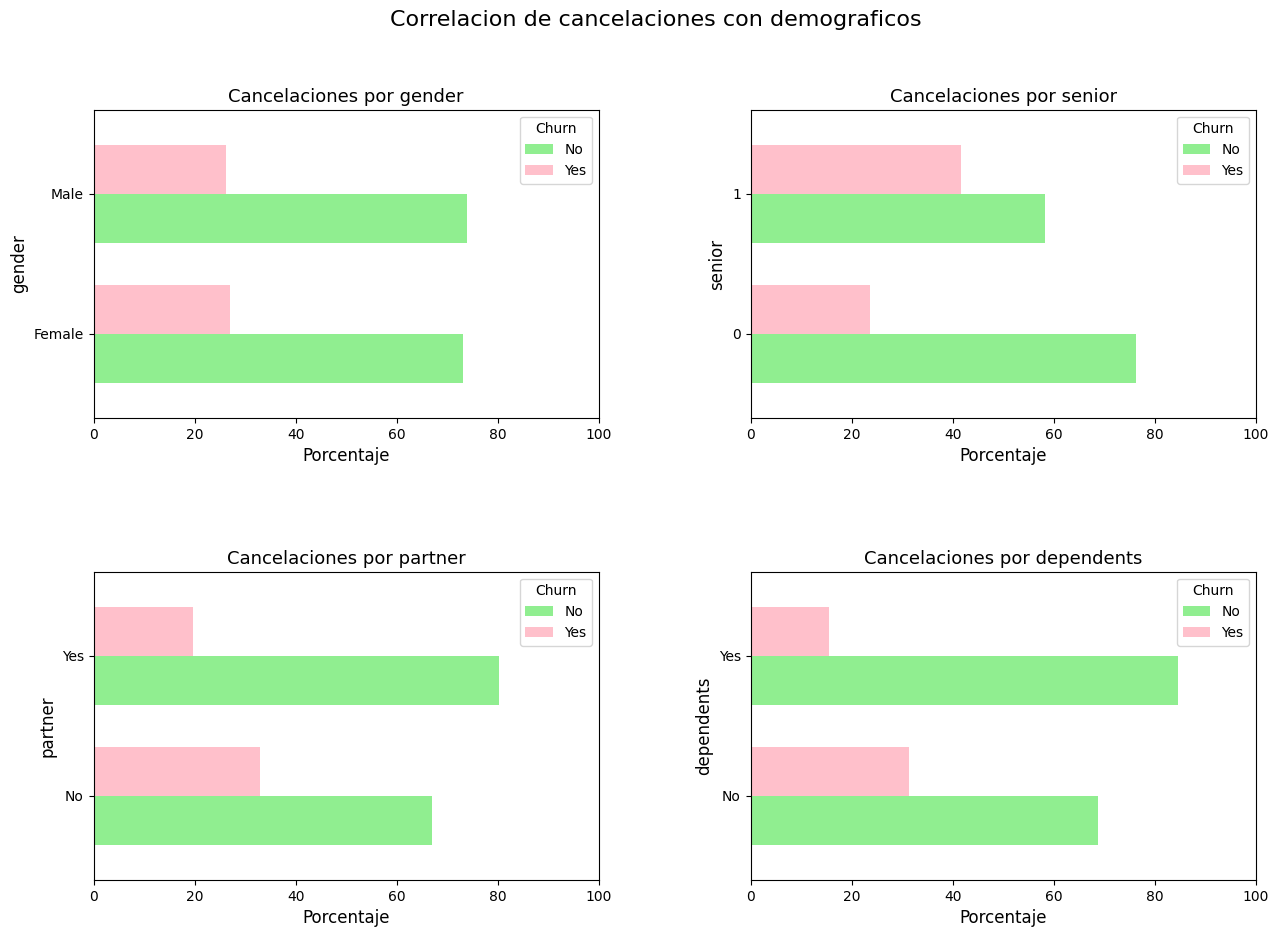

In [81]:
import matplotlib.pyplot as plt

demographic = ['gender','senior','partner','dependents']
fig, axs = plt.subplots(2,2, figsize=(15,10))
axs = axs.ravel()
fig.subplots_adjust(hspace=0.5,wspace=0.3)
fig.suptitle('Correlacion de cancelaciones con demograficos', fontsize=16)
ymin = 0
ymax = 100

for x,y in enumerate(demographic):
  churn_demographic = pd.crosstab(df[y], df['churn'], normalize='index')*100
  churn_demographic.plot(kind='barh', ax=axs[x], color=['lightgreen', 'pink'], width=0.7)

  axs[x].set_title(f'Cancelaciones por {y}', fontsize=13)
  axs[x].set_ylabel(y, fontsize=12)
  axs[x].set_xlabel('Porcentaje', fontsize=12)
  axs[x].legend(title='Churn', labels=['No', 'Yes'])
  axs[x].set_xlim(ymin,ymax)

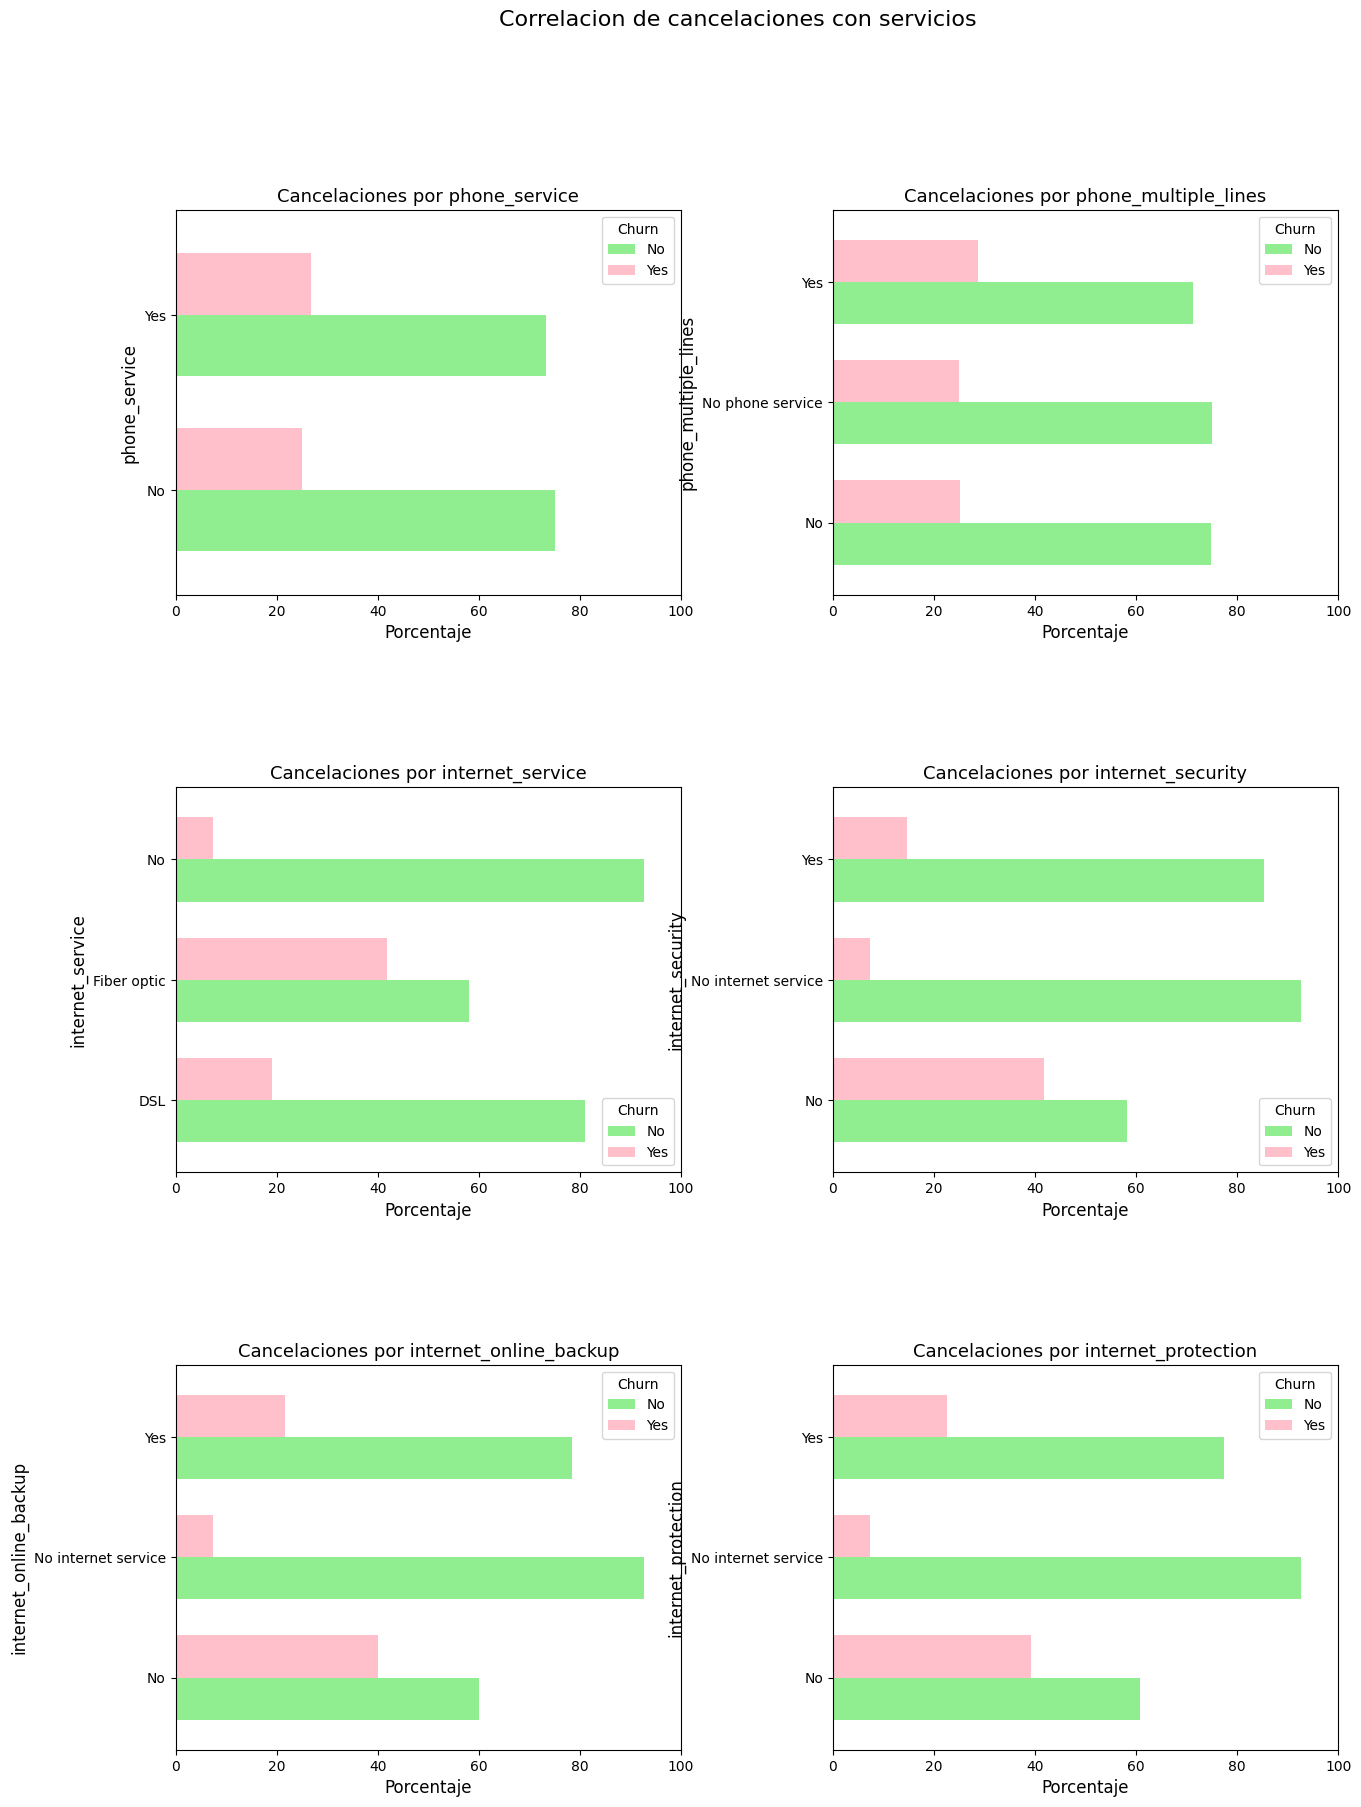

In [85]:
import matplotlib.pyplot as plt

demographic = ['phone_service', 'phone_multiple_lines', 'internet_service', 'internet_security', 'internet_online_backup', 'internet_protection']
fig, axs = plt.subplots(3,2, figsize=(15,20))
axs = axs.ravel()
fig.subplots_adjust(hspace=0.5,wspace=0.3)
fig.suptitle('Correlacion de cancelaciones con servicios', fontsize=16)
ymin = 0
ymax = 100

for x,y in enumerate(demographic):
  churn_demographic = pd.crosstab(df[y], df['churn'], normalize='index')*100
  churn_demographic.plot(kind='barh', ax=axs[x], color=['lightgreen', 'pink'], width=0.7)

  axs[x].set_title(f'Cancelaciones por {y}', fontsize=13)
  axs[x].set_ylabel(y, fontsize=12)
  axs[x].set_xlabel('Porcentaje', fontsize=12)
  axs[x].legend(title='Churn', labels=['No', 'Yes'])
  axs[x].set_xlim(ymin,ymax)

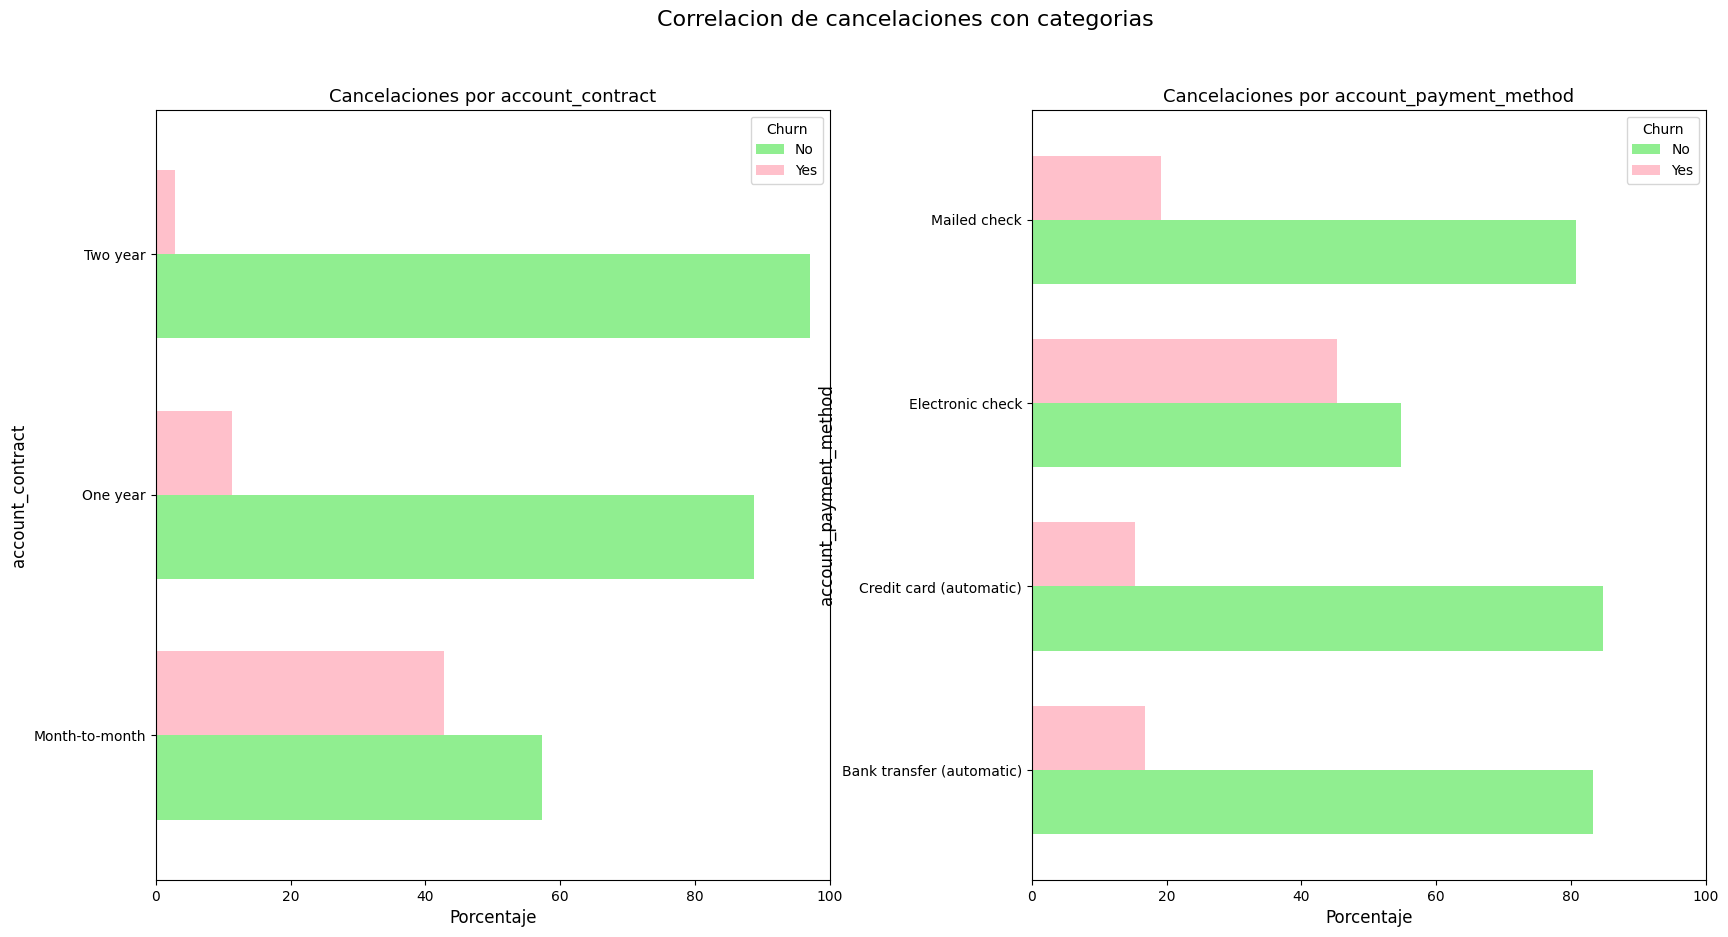

In [90]:
import matplotlib.pyplot as plt

demographic = ['account_contract', 'account_payment_method']
fig, axs = plt.subplots(1,2, figsize=(20,10))
axs = axs.ravel()
fig.subplots_adjust(hspace=0.5,wspace=0.3)
fig.suptitle('Correlacion de cancelaciones con categorias', fontsize=16)
ymin = 0
ymax = 100

for x,y in enumerate(demographic):
  churn_demographic = pd.crosstab(df[y], df['churn'], normalize='index')*100
  churn_demographic.plot(kind='barh', ax=axs[x], color=['lightgreen', 'pink'], width=0.7)

  axs[x].set_title(f'Cancelaciones por {y}', fontsize=13)
  axs[x].set_ylabel(y, fontsize=12)
  axs[x].set_xlabel('Porcentaje', fontsize=12)
  axs[x].legend(title='Churn', labels=['No', 'Yes'])
  axs[x].set_xlim(ymin,ymax)

##Conteo de evasión por variables numéricas

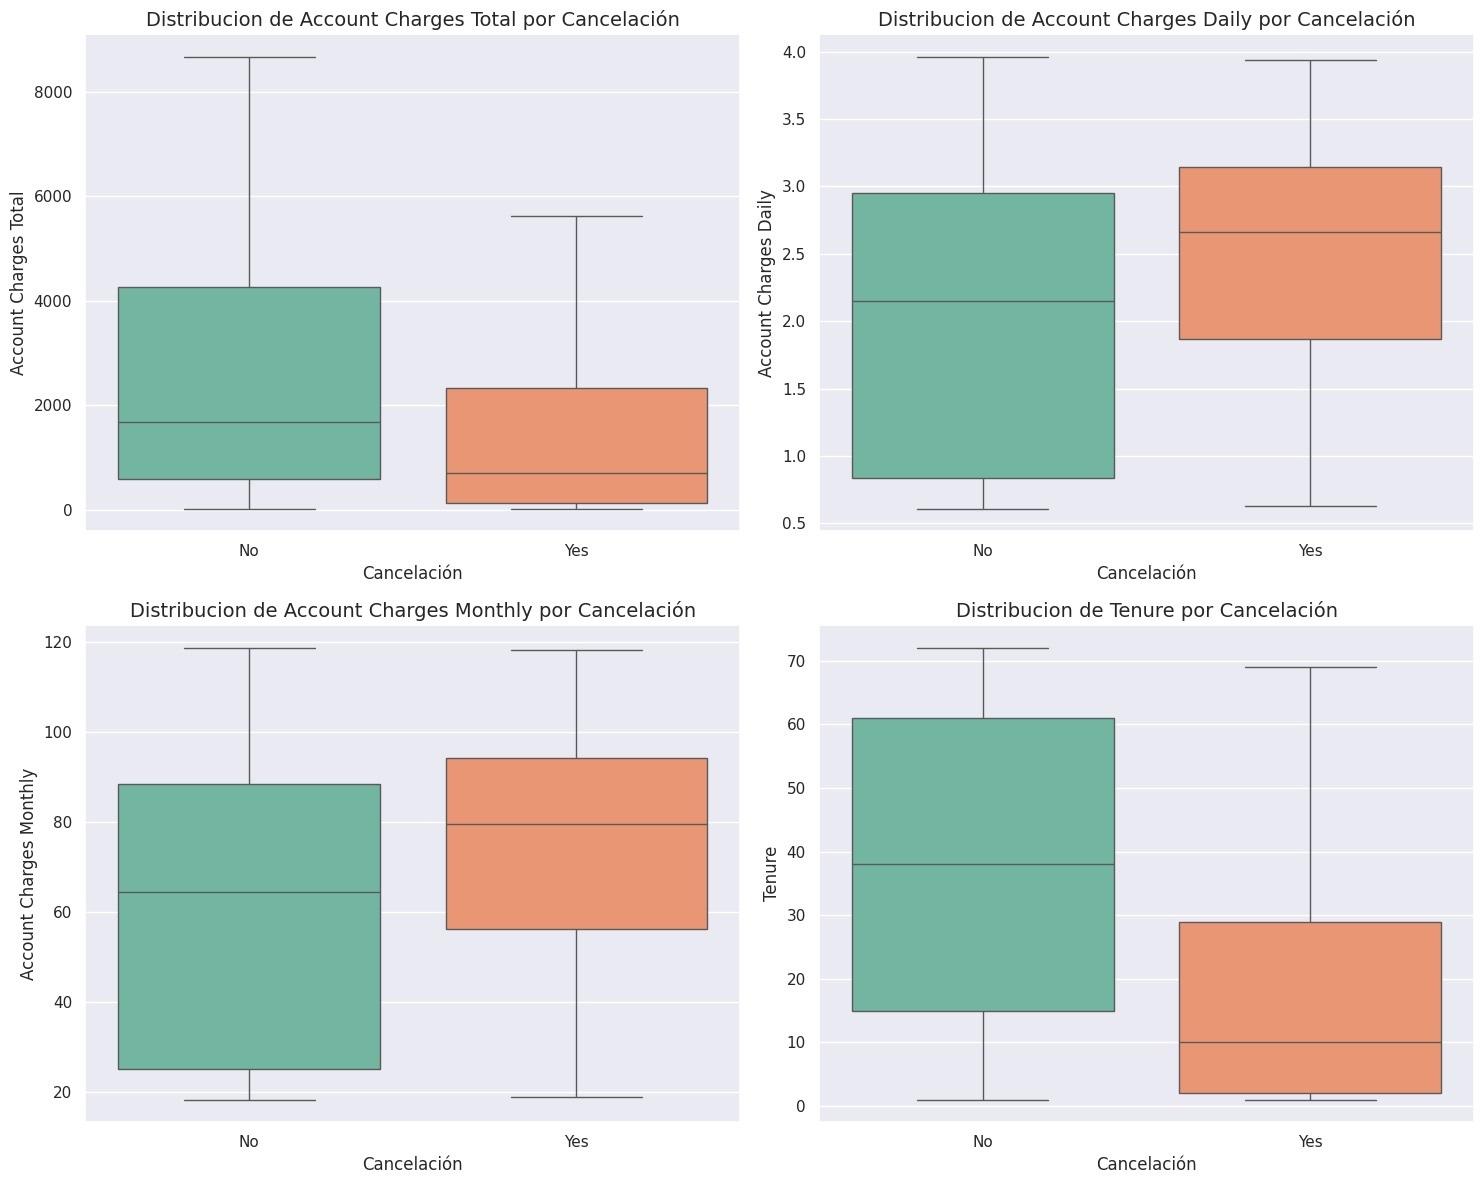

In [100]:
import seaborn as sns
sns.set_theme()
cols_to_plot = [
    'account_charges_total',
    'account_charges_daily',
    'account_charges_monthly',
    'tenure'
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()


for i, col in enumerate(cols_to_plot):
    sns.boxplot(
        x='churn',
        y=col,
        data=df,
        ax=axes[i],
        palette='Set2',
        hue='churn',
        showfliers=False
    )
    axes[i].set_title(f'Distribucion de {col.replace("_", " ").title()} por Cancelación', fontsize=14)
    axes[i].set_xlabel('Cancelación', fontsize=12)
    axes[i].set_ylabel(col.replace("_", " ").title(), fontsize=12)

plt.tight_layout()
plt.show()

#📄Informe final

###**Introducción**

Analizar las estadísticas de Churn (Abandono/Evasión de Clientes) en una compañía es vital, ya que conseguir un cliente nuevo es más difícil que mantener a uno actual, por eso basamos esta investigación en este dato crucial para averiguar cuales son las principales causas y demográficos asociados con este problema.

Se observa que aproximadamente el 26.5% de los clientes han cancelado el servicio, esto puede ser por múltiples razones como un declive en la calidad del servicio o un aumento en los costos. Se analizarán multiples factores para poder saber porque uno de cada cuatro clientes está cancelando su contrato.

###**Limpieza y tratamiento de datos**

Primero se normalizó el dataset ya que este venía anidado de tal forma que
se encontraban diccionarios dentro de las columnas.

Después en el manejo de inconsistencias a pesar de no haber encontrado filas con null se encontraron valores vacios ('') y blancos (' ') en las columnas churn y cargos totales, por lo que se realizó una purga borrando las filas que contenían estos datos.

Finalmente para mantener un index sin saltos entre numeros lo reseteamos con index_reset y cambiamos el nombre de las columnas a uno más adecuado para mejor legibilidad. Además se agregó una nueva columna con el cálculo del gasto diario de cada cliente.

###**Análisis exploratorio de datos**



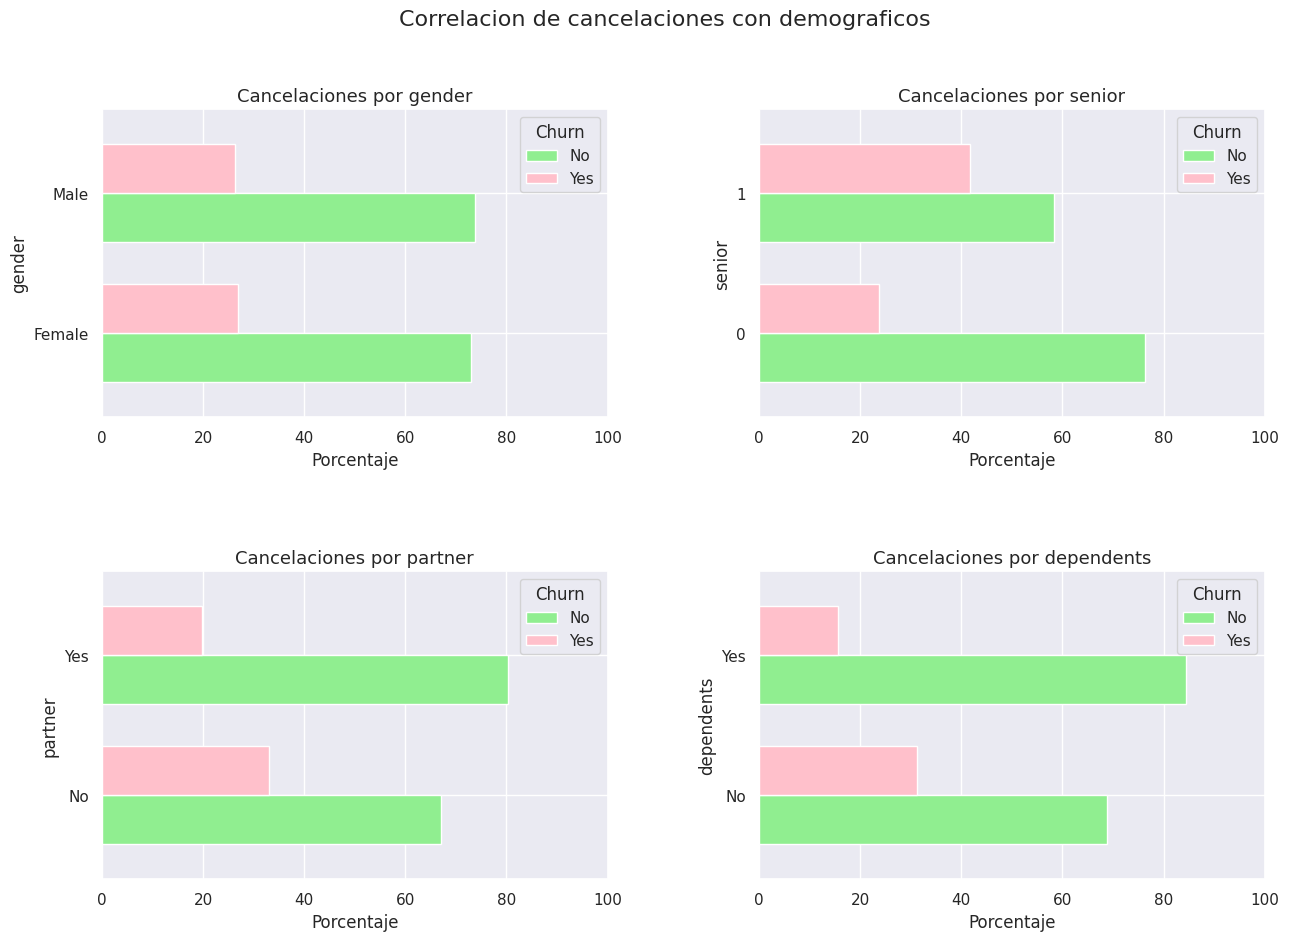

In [101]:
import matplotlib.pyplot as plt

demographic = ['gender','senior','partner','dependents']
fig, axs = plt.subplots(2,2, figsize=(15,10))
axs = axs.ravel()
fig.subplots_adjust(hspace=0.5,wspace=0.3)
fig.suptitle('Correlacion de cancelaciones con demograficos', fontsize=16)
ymin = 0
ymax = 100

for x,y in enumerate(demographic):
  churn_demographic = pd.crosstab(df[y], df['churn'], normalize='index')*100
  churn_demographic.plot(kind='barh', ax=axs[x], color=['lightgreen', 'pink'], width=0.7)

  axs[x].set_title(f'Cancelaciones por {y}', fontsize=13)
  axs[x].set_ylabel(y, fontsize=12)
  axs[x].set_xlabel('Porcentaje', fontsize=12)
  axs[x].legend(title='Churn', labels=['No', 'Yes'])
  axs[x].set_xlim(ymin,ymax)

**Correlaciones con datos demográficos**

El hayazgo más importante de este primer set de gráficos fue el factor "Senior", el gráfico de la derecha arriba nos muestra que los clientes que son adultos mayores se están yendo de nuestra compañía de manera masiva (más del 40% de ellos), lo que podría indicar que el servicio es difícil de usar o que los planes no se ajustan a este sector demográfico en específico.

Encontramos también que aquellas personas sin pareja y sin dependientes son más propensos a cancelar (más del 30%), esto podría ser a que como este sector tiene menos barrera de salida para ellos cambiar de proveedor es más fácil.

En cambio analizando las gráficas del factor género podemos ver como presentan datos muy similares, una distribución prácticamente idéntica, por lo que el genero parece no ser una variable determinante.



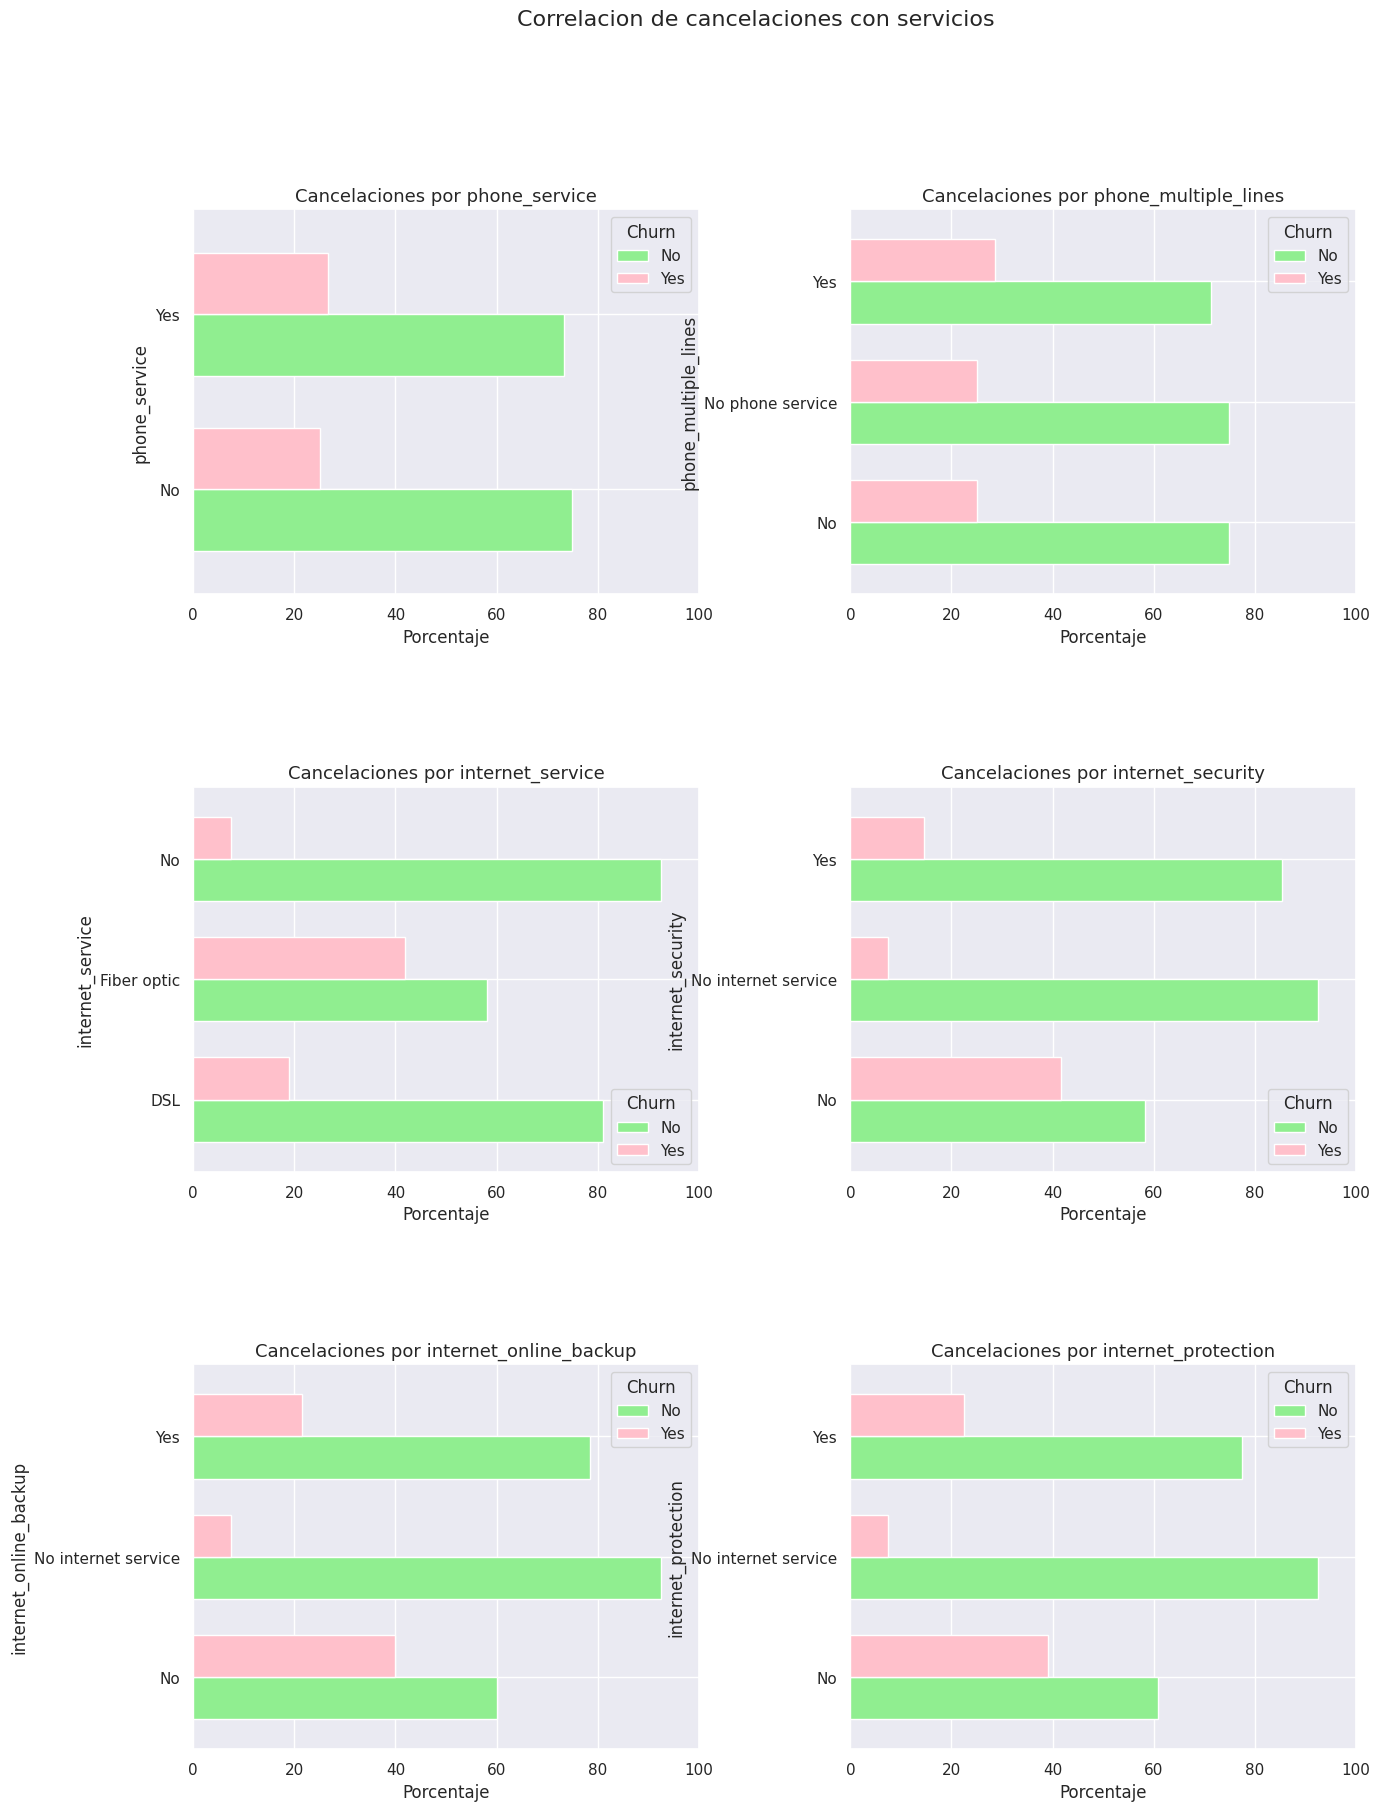

In [102]:
import matplotlib.pyplot as plt

demographic = ['phone_service', 'phone_multiple_lines', 'internet_service', 'internet_security', 'internet_online_backup', 'internet_protection']
fig, axs = plt.subplots(3,2, figsize=(15,20))
axs = axs.ravel()
fig.subplots_adjust(hspace=0.5,wspace=0.3)
fig.suptitle('Correlacion de cancelaciones con servicios', fontsize=16)
ymin = 0
ymax = 100

for x,y in enumerate(demographic):
  churn_demographic = pd.crosstab(df[y], df['churn'], normalize='index')*100
  churn_demographic.plot(kind='barh', ax=axs[x], color=['lightgreen', 'pink'], width=0.7)

  axs[x].set_title(f'Cancelaciones por {y}', fontsize=13)
  axs[x].set_ylabel(y, fontsize=12)
  axs[x].set_xlabel('Porcentaje', fontsize=12)
  axs[x].legend(title='Churn', labels=['No', 'Yes'])
  axs[x].set_xlim(ymin,ymax)

**Correlaciones con datos del tipo de servicio**

Este set de gráficos nos indican factores técnicos que podrían estar orillando a los clientes a cancelar.

El principal problema de este grupo de servicios analizados es la fibra óptica. Mientras que los clientes con DSL tienen una tasa de abandono baja (cerca del 19%), los clientes de fibra óptica tienen un abandono alarmante de aproximadamente el 42%. La fibra óptica debería ser el producto estrella por su velocidad, pero algo aquí está fallando, ya sea el precio del servicio, la estabilidad o la velocidad.

Por otro lado los clientes que si tienen servicios de seguridad contratados tienen una tasa de cancelacion más bajo (15%) que los que no cuentan con ellos (40%), esto sugiere que si el cliente siente que cuenta con una conexion genérica que no tiene los niveles de seguridad premium entonces es más fácil cambiar en cualquier momento de proveedor.

Los servicios telefónicos no presentan mucha diferencia en las estadísticas de abandono, por lo que es muy probable que el problema de la empresa no esté relacionado a la telefonía si no al servicio de internet y los servicios de protección ligados.

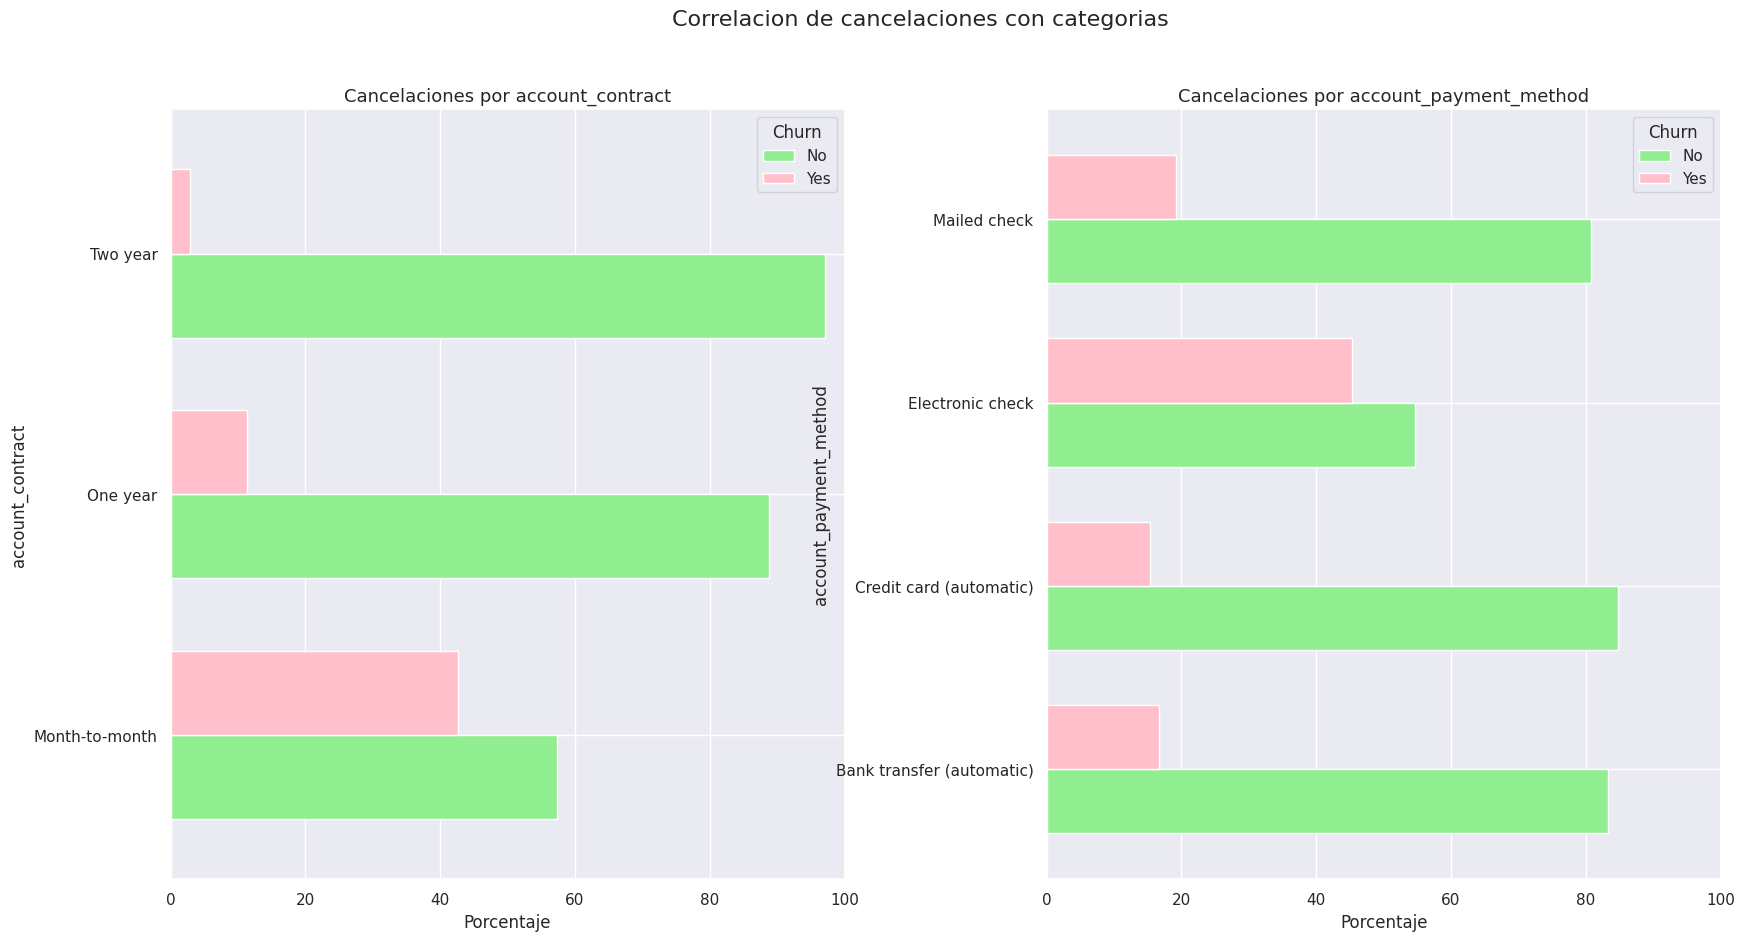

In [103]:
import matplotlib.pyplot as plt

demographic = ['account_contract', 'account_payment_method']
fig, axs = plt.subplots(1,2, figsize=(20,10))
axs = axs.ravel()
fig.subplots_adjust(hspace=0.5,wspace=0.3)
fig.suptitle('Correlacion de cancelaciones con categorias', fontsize=16)
ymin = 0
ymax = 100

for x,y in enumerate(demographic):
  churn_demographic = pd.crosstab(df[y], df['churn'], normalize='index')*100
  churn_demographic.plot(kind='barh', ax=axs[x], color=['lightgreen', 'pink'], width=0.7)

  axs[x].set_title(f'Cancelaciones por {y}', fontsize=13)
  axs[x].set_ylabel(y, fontsize=12)
  axs[x].set_xlabel('Porcentaje', fontsize=12)
  axs[x].legend(title='Churn', labels=['No', 'Yes'])
  axs[x].set_xlim(ymin,ymax)

**Correlaciones con datos del tipo de contrato y pago**

El análisis de este conjunto de valores nos revela que la estructura comercial de la empresa facilita que los clientes abandonen la misma.

El problema principal es el contrato mensual, los clientes que tienen este tipo de contrato tienen una tasa de cancelación masiva, superior al 40%, en cambio en contraste los clientes que tienen contratos de uno o soa años tienen una tasa de menos del 10%.

También encontramos que el proceso del pago por cheque electrónico presenta un abandono cercano al 45%, por lo que puede estar presentando problemas en el proceso o ser muy difícil de realizar.

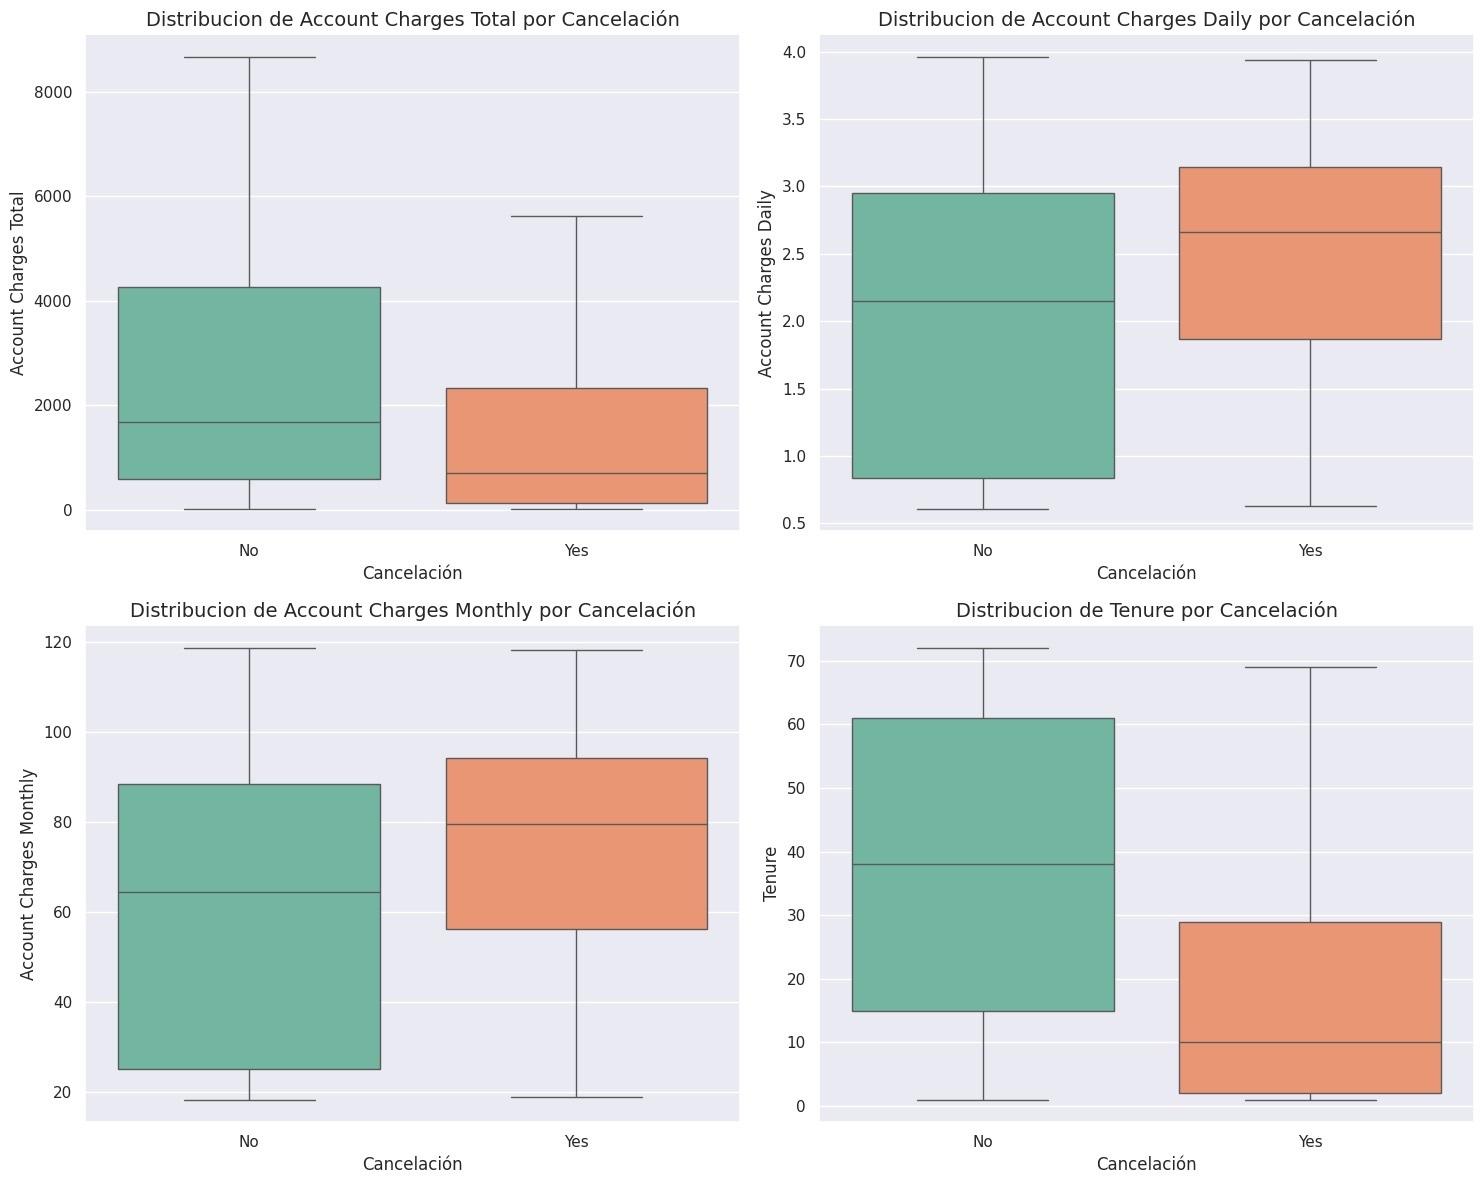

In [104]:
import seaborn as sns
sns.set_theme()
cols_to_plot = [
    'account_charges_total',
    'account_charges_daily',
    'account_charges_monthly',
    'tenure'
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()


for i, col in enumerate(cols_to_plot):
    sns.boxplot(
        x='churn',
        y=col,
        data=df,
        ax=axes[i],
        palette='Set2',
        hue='churn',
        showfliers=False
    )
    axes[i].set_title(f'Distribucion de {col.replace("_", " ").title()} por Cancelación', fontsize=14)
    axes[i].set_xlabel('Cancelación', fontsize=12)
    axes[i].set_ylabel(col.replace("_", " ").title(), fontsize=12)

plt.tight_layout()
plt.show()

**Distribución de los datos con respecto a los gastos (totales, mensuales y diarios) y antigüedad**

Para cerrar este análisis usamos gráficos del tipo boxplot de variables numéricas, estos datos nos ayudan a completar el perfil del cliente que estamos perdiendo.

Analizando la antigüedad nos damos cuenta que la mediana de los clientes que cancelan lo hacen en una etapa muy temprana (al rededor de los 10 meses) y los clientes que no lo hacen tienen una media de 40 meses aproximadamente, por lo que tenemos una diferencia visiblemente grande y alarmante. Además podemos darnos cuenta que si logramos que el cliente pase la barrera de los 20 meses la probabilidad de que se quede con nosotros aumenta drásticamente.

Por último podemos ver que los clientes que tienen en promedio cargos mensuales y diarios más áltos son los que están mas propensos a cancelar el servicio, esto nos indica que los clientes que se están yendo son los que más pagan y vemos como podría estar relacionado al problema de la fibra óptica.



###Conclusiones y Recomendaciones

* Conclusión #1: Tenemos un problema con el servicio de fibra óptica

* Recomendación: Es urgente investigar por qué el servicio más caro e importante tiene el doble de abandono que el DSL, si existen problemas técnicos hay que remediarlos y si el problema es de competitividad de precios con la competencia hay que ajustarlo de manera que sea más atractivo.

* Conclusión #2: Necesitamos un plan de retención de nuevos clientes

* Recomendación: Implementar descuentos o beneficios especiales para nuevos clientes y sobre todo un descuento que se active en el mes 6 y el 18 para superar la barrera crítica de antigüedad de la que hablabamos en el análisis (20 meses).

* Conclusión #3: Es necesario aumentar las ventas de los servicios de seguridad

* Recomendación: Incentivar al cliente a obtener los servicios de seguridad de internet y el online backup a través de campañas de información acerca de los beneficios que otorgan estos servicios. Los clientes que cuentan actualmente con estos extras tienen una retención mas elevada que los que no.

* Conclusión #4: Mejorar el servicio y atención a los adultos mayores

* Recomendación: Crear canales de soporte y planes simplificados para este grupo demográfico. Revisar la complejidad de las interfaces y ofrecer un modo de mas fácil acceso a los servicios. La fuga de este sector es desproporcionada, se recomienda encuestar a los clientes de este grupo para detectar problemas que pueden tener con nuestros servicios.

* Conclusión #5: Aumentar el número de clientes con contratos largos.

* Recomendación: Incentivar el cambio de contrato a nuestros clientes que cuentan con una facturación de "mes a mes" para que cambien por una "anual" ofreciendo un mes de servicio gratuito si realizan este sencillo cambio.

